# Style Snapped — Model Visualizations
Five publication-ready charts illustrating the architecture and data story behind the Style Snapped models.

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42
rng = np.random.default_rng(SEED)
print('Setup complete.')

Setup complete.


## 1 · Style Embedding Space (3-D scatter)

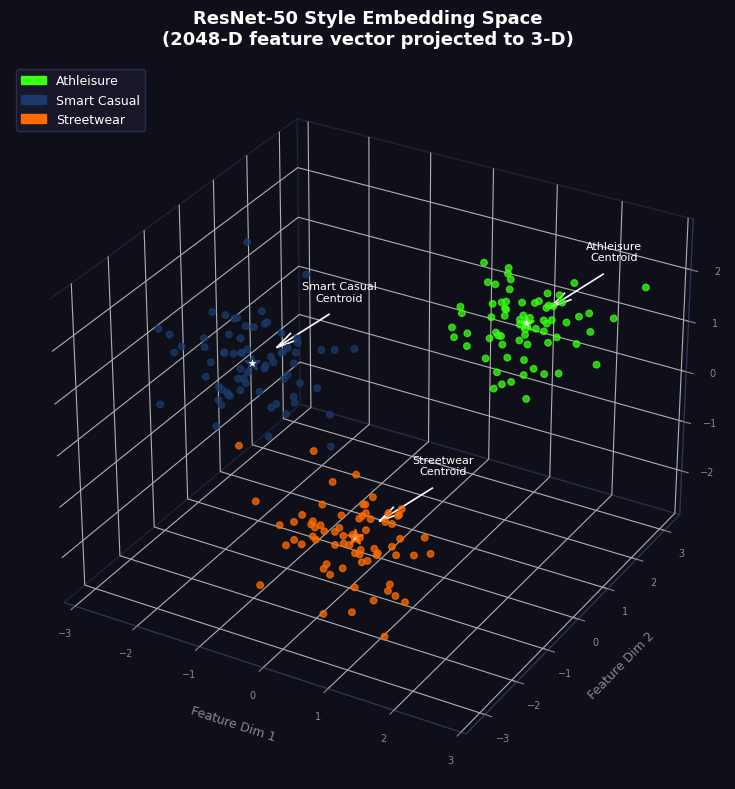

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

clusters = [
    ('Athleisure',   '#39ff14', (1.5,  1.5,  1.5), 70),
    ('Smart Casual', '#1a3a6b', (-1.5, -1.0,  1.0), 70),
    ('Streetwear',   '#ff6b00', (0.5, -1.8, -1.2), 70),
]

handles = []
for label, color, center, n in clusters:
    pts = rng.normal(loc=center, scale=0.55, size=(n, 3))
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
               c=color, s=22, alpha=0.75, depthshade=True, label=label)

    cx, cy, cz = center
    ax.scatter([cx], [cy], [cz], c='white', s=120, marker='*',
               edgecolors=color, linewidths=1.5, zorder=5)

    ax.quiver(cx + 0.8, cy + 0.8, cz + 0.8,
              -0.55, -0.55, -0.55,
              color='white', linewidth=1.2, arrow_length_ratio=0.35)
    ax.text(cx + 0.9, cy + 0.9, cz + 1.0,
            f'{label}\nCentroid', color='white', fontsize=8,
            ha='center', va='bottom')
    handles.append(mpatches.Patch(color=color, label=label))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor('#333355')
ax.tick_params(colors='#888888', labelsize=7)
ax.set_xlabel('Feature Dim 1', color='#888888', fontsize=9, labelpad=8)
ax.set_ylabel('Feature Dim 2', color='#888888', fontsize=9, labelpad=8)
ax.set_zlabel('Feature Dim 3', color='#888888', fontsize=9, labelpad=8)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.line.set_color('#333355')

ax.set_title('ResNet-50 Style Embedding Space\n(2048-D feature vector projected to 3-D)',
             color='white', fontsize=13, pad=14, fontweight='bold')

legend = ax.legend(handles=handles, loc='upper left',
                   facecolor='#1a1a2e', edgecolor='#333355',
                   labelcolor='white', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('01_embedding_space.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 2 · Model 1 Class Distribution (horizontal bar chart)

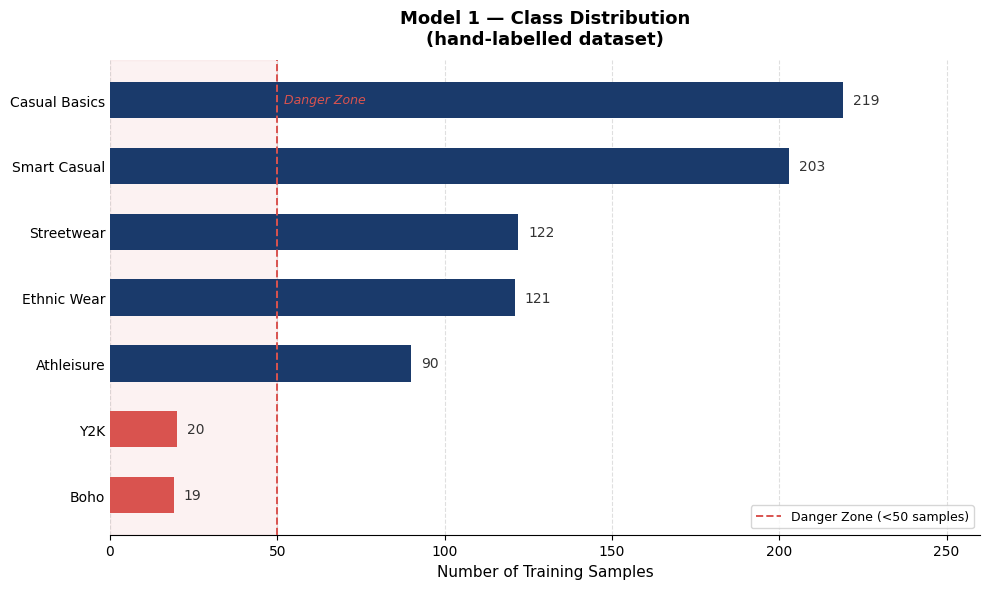

In [5]:
classes = ['Casual Basics', 'Smart Casual', 'Streetwear', 'Ethnic Wear', 'Athleisure', 'Y2K', 'Boho']
counts  = [219, 203, 122, 121, 90, 20, 19]
DANGER  = 50
NAVY    = '#1a3a6b'
DANGER_COLOR = '#d9534f'
GRAY    = '#cccccc'

order = np.argsort(counts)
classes_s = [classes[i] for i in order]
counts_s  = [counts[i]  for i in order]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

colors = [DANGER_COLOR if c < DANGER else NAVY for c in counts_s]
bars = ax.barh(classes_s, counts_s, color=colors, height=0.55, zorder=3)

ax.axvspan(0, DANGER, alpha=0.07, color=DANGER_COLOR, zorder=1)
ax.axvline(DANGER, color=DANGER_COLOR, linestyle='--', linewidth=1.4,
           label=f'Danger Zone (<{DANGER} samples)', zorder=4)

ax.text(DANGER + 2, len(classes_s) - 1.05, 'Danger Zone',
        color=DANGER_COLOR, fontsize=9, fontstyle='italic')

for bar, val in zip(bars, counts_s):
    ax.text(val + 3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=10, color='#333333')

ax.set_xlabel('Number of Training Samples', fontsize=11)
ax.set_title('Model 1 — Class Distribution\n(hand-labelled dataset)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 260)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Cluster-to-Label Workflow Diagram

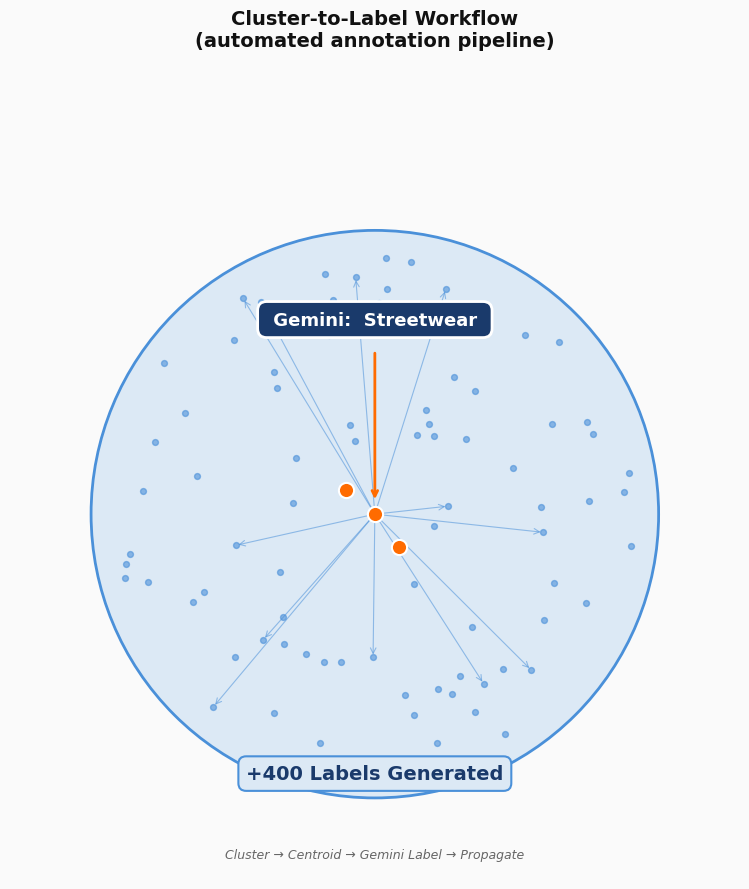

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 5.5)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#fafafa')

CLUSTER_R = 3.5
cluster_bg = plt.Circle((0, 0), CLUSTER_R, color='#dce9f5', zorder=1)
cluster_ring = plt.Circle((0, 0), CLUSTER_R, fill=False,
                           edgecolor='#4a90d9', linewidth=2, zorder=2)
ax.add_patch(cluster_bg)
ax.add_patch(cluster_ring)

rng2 = np.random.default_rng(7)
dot_xs, dot_ys = [], []
while len(dot_xs) < 80:
    x, y = rng2.uniform(-CLUSTER_R, CLUSTER_R, 2)
    if x**2 + y**2 < (CLUSTER_R - 0.25)**2 and x**2 + y**2 > 0.7**2:
        dot_xs.append(x)
        dot_ys.append(y)
ax.scatter(dot_xs, dot_ys, c='#4a90d9', s=18, alpha=0.6, zorder=3)

centroid_offsets = [(0.0, 0.0), (0.3, -0.4), (-0.35, 0.3)]
for cx, cy in centroid_offsets:
    ax.scatter([cx], [cy], c='#ff6b00', s=120, zorder=6,
               edgecolors='white', linewidths=1.5)

label_x, label_y = 0.0, 2.4
bbox_props = dict(boxstyle='round,pad=0.5', facecolor='#1a3a6b',
                  edgecolor='white', linewidth=2)
ax.text(label_x, label_y, ' Gemini:  Streetwear ',
        ha='center', va='center', fontsize=13, color='white',
        fontweight='bold', bbox=bbox_props, zorder=7)

ax.annotate('', xy=(0.0, 0.15), xytext=(label_x, label_y - 0.38),
            arrowprops=dict(arrowstyle='->', color='#ff6b00', lw=2), zorder=7)

sample_targets = list(zip(dot_xs[:12], dot_ys[:12]))
for tx, ty in sample_targets:
    ax.annotate('', xy=(tx, ty), xytext=(0.0, 0.0),
                arrowprops=dict(arrowstyle='->', color='#4a90d9',
                                lw=0.8, alpha=0.55), zorder=4)

ax.text(0.0, -3.2, '+400 Labels Generated', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#1a3a6b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#dce9f5',
                  edgecolor='#4a90d9', linewidth=1.5))

ax.text(0, -4.2, 'Cluster → Centroid → Gemini Label → Propagate',
        ha='center', va='center', fontsize=9, color='#666666', style='italic')

ax.set_title('Cluster-to-Label Workflow\n(automated annotation pipeline)',
             fontsize=14, fontweight='bold', pad=16, color='#111111')

plt.tight_layout()
plt.savefig('03_cluster_to_label.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## 4 · Two-Phase Training Accuracy

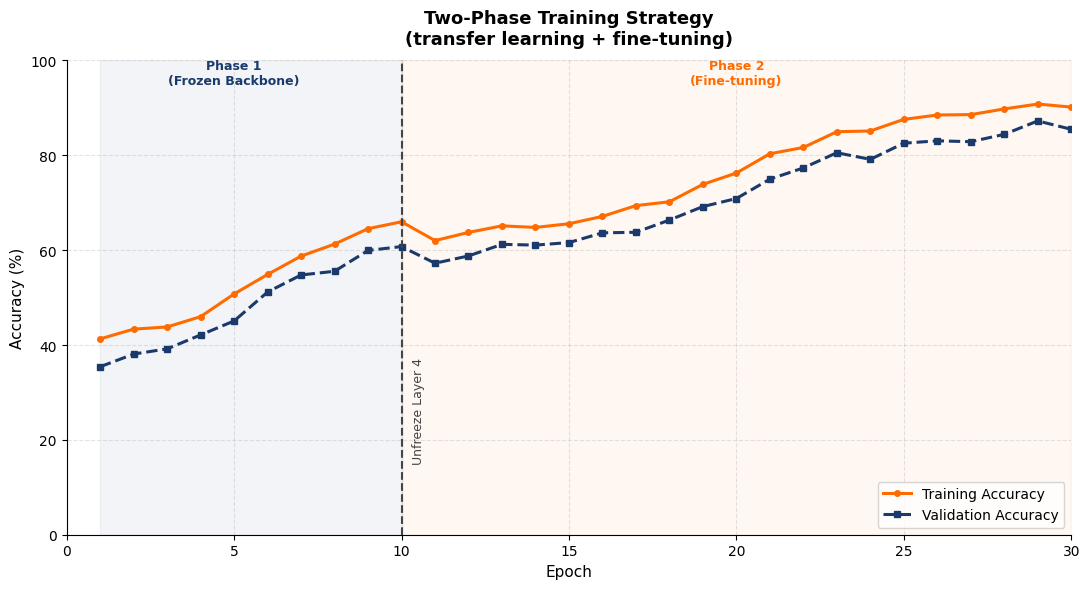

In [7]:
EPOCHS     = 30
UNFREEZE   = 10
epochs     = np.arange(1, EPOCHS + 1)

def sigmoid_curve(x, lo, hi, mid, k):
    return lo + (hi - lo) / (1 + np.exp(-k * (x - mid)))

train_acc = np.where(
    epochs <= UNFREEZE,
    sigmoid_curve(epochs, 38, 68, 5.5, 0.55),
    sigmoid_curve(epochs, 62, 91, 20, 0.38)
) + rng.normal(0, 0.6, EPOCHS)

val_acc = train_acc - rng.uniform(3, 6, EPOCHS)
train_acc = np.clip(train_acc, 0, 96)
val_acc   = np.clip(val_acc,   0, 93)

ORANGE = '#ff6b00'
NAVY   = '#1a3a6b'

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')

ax.fill_between(epochs[epochs <= UNFREEZE], 0, 100,
                alpha=0.05, color=NAVY, label='_nolegend_')
ax.fill_between(epochs[epochs >= UNFREEZE], 0, 100,
                alpha=0.05, color=ORANGE, label='_nolegend_')

ax.plot(epochs, train_acc, color=ORANGE, linewidth=2.2,
        marker='o', markersize=4, label='Training Accuracy')
ax.plot(epochs, val_acc, color=NAVY, linewidth=2.2,
        marker='s', markersize=4, linestyle='--', label='Validation Accuracy')

ax.axvline(UNFREEZE, color='#444444', linestyle='--', linewidth=1.5, zorder=5)
ax.text(UNFREEZE + 0.3, 15, 'Unfreeze Layer 4',
        color='#444444', fontsize=9, rotation=90, va='bottom')

ax.text(5, 95, 'Phase 1\n(Frozen Backbone)', ha='center',
        fontsize=9, color=NAVY, fontweight='bold')
ax.text(20, 95, 'Phase 2\n(Fine-tuning)', ha='center',
        fontsize=9, color=ORANGE, fontweight='bold')

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xlim(1, EPOCHS)
ax.set_ylim(0, 100)
ax.set_xticks(range(0, EPOCHS + 1, 5))
ax.legend(fontsize=10, loc='lower right')
ax.grid(linestyle='--', alpha=0.35)
ax.set_title('Two-Phase Training Strategy\n(transfer learning + fine-tuning)',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('04_two_phase_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · The Impact of Data Scaling

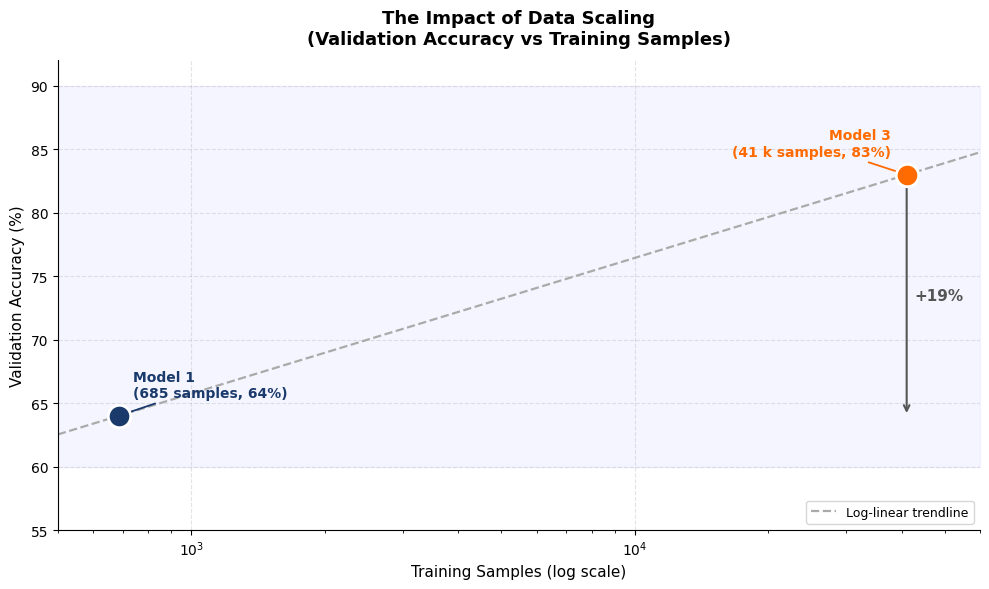

In [8]:
points = np.array([[685, 64], [41000, 83]])
labels = ['Model 1\n(685 samples, 64%)', 'Model 3\n(41 k samples, 83%)']
colors = ['#1a3a6b', '#ff6b00']

x = points[:, 0]
y = points[:, 1]

m, b = np.polyfit(np.log10(x), y, 1)
x_trend = np.logspace(np.log10(500), np.log10(60000), 200)
y_trend = m * np.log10(x_trend) + b

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

ax.plot(x_trend, y_trend, '--', color='#aaaaaa', linewidth=1.6,
        label='Log-linear trendline', zorder=2)

for (xi, yi), lbl, col in zip(points, labels, colors):
    ax.scatter([xi], [yi], s=260, color=col, zorder=5,
               edgecolors='white', linewidths=2)
    offset_x = xi * 1.08 if col == '#1a3a6b' else xi * 0.92
    ha = 'left' if col == '#1a3a6b' else 'right'
    ax.annotate(lbl, xy=(xi, yi), xytext=(offset_x, yi + 1.5),
                fontsize=10, color=col, fontweight='bold', ha=ha,
                arrowprops=dict(arrowstyle='->', color=col, lw=1.3))

ax.fill_betweenx([60, 90], 500, 60000, alpha=0.04, color='blue')

ax.set_xscale('log')
ax.set_xlim(500, 60000)
ax.set_ylim(55, 92)
ax.set_xlabel('Training Samples (log scale)', fontsize=11)
ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
ax.set_title('The Impact of Data Scaling\n(Validation Accuracy vs Training Samples)',
             fontsize=13, fontweight='bold', pad=12)
ax.grid(linestyle='--', alpha=0.35)
ax.legend(fontsize=9, loc='lower right')

delta = y[1] - y[0]
ax.annotate('', xy=(x[1], y[1]), xytext=(x[1], y[0]),
            arrowprops=dict(arrowstyle='<->', color='#555555', lw=1.5))
ax.text(x[1] * 1.04, (y[0] + y[1]) / 2, f'+{delta:.0f}%',
        color='#555555', fontsize=11, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('05_data_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · System Architecture Diagram

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Canvas ──────────────────────────────────────────────────────────────────
BG      = '#0f172a'
BOX_BG  = '#1e293b'
ORANGE  = '#f97316'
WHITE   = '#f8fafc'
GRAY    = '#94a3b8'
MONO    = 'DejaVu Sans Mono'

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

# ── Helper ──────────────────────────────────────────────────────────────────
def fancy_box(x, y, w, h, label, body_lines):
    """Draw a rounded box with an orange header bar and monospaced body text."""
    # Shadow
    shadow = patches.FancyBboxPatch(
        (x + 0.08, y - 0.08), w, h,
        boxstyle='round,pad=0.05',
        linewidth=0, facecolor='#000000', alpha=0.4, zorder=1
    )
    ax.add_patch(shadow)

    # Main box
    box = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.05',
        linewidth=2, edgecolor=ORANGE,
        facecolor=BOX_BG, zorder=2
    )
    ax.add_patch(box)

    # Header bar
    header_h = 0.72
    header = patches.FancyBboxPatch(
        (x, y + h - header_h), w, header_h,
        boxstyle='round,pad=0.05',
        linewidth=0, facecolor=ORANGE, zorder=3
    )
    ax.add_patch(header)

    # Header text
    ax.text(x + w / 2, y + h - header_h / 2, label,
            ha='center', va='center', fontsize=11.5,
            fontweight='bold', color='white', zorder=4)

    # Body lines
    line_h   = (h - header_h - 0.3) / max(len(body_lines), 1)
    for i, line in enumerate(body_lines):
        ty = y + h - header_h - 0.25 - (i + 0.5) * line_h
        ax.text(x + 0.28, ty, line,
                ha='left', va='center',
                fontsize=9.5, color=WHITE,
                fontfamily=MONO, zorder=4)

# ── Left box: React Frontend ─────────────────────────────────────────────────
fancy_box(
    x=0.6, y=1.2, w=4.0, h=4.6,
    label='React Frontend  (Vite + Tailwind)',
    body_lines=[
        '[ Drag & Drop Upload ]',
        '[ Image Preview      ]',
        '[ Check Vibe Button  ]',
        '[ Result Badge       ]',
    ]
)

# ── Right box: FastAPI Backend ───────────────────────────────────────────────
fancy_box(
    x=9.4, y=1.2, w=4.0, h=4.6,
    label='FastAPI Backend  (Uvicorn + PyTorch)',
    body_lines=[
        'POST /predict',
        '├─ PIL decode',
        '├─ Resize → Normalize (224×224)',
        '├─ ResNet-50 forward pass',
        '├─ Softmax → top-3 confidence %',
        '└─ classes.json → aesthetic label',
    ]
)

# ── Centre connection zone ───────────────────────────────────────────────────
MID_LEFT  = 4.62   # right edge of left box
MID_RIGHT = 9.38   # left edge of right box
ARROW_Y_TOP = 4.10
ARROW_Y_BOT = 2.90

# Top arrow: L → R  (FormData)
ax.annotate(
    '', xy=(MID_RIGHT, ARROW_Y_TOP), xytext=(MID_LEFT, ARROW_Y_TOP),
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=2.2,
                    connectionstyle='arc3,rad=0.0'),
    zorder=5
)
ax.text((MID_LEFT + MID_RIGHT) / 2, ARROW_Y_TOP + 0.28,
        'FormData  (Image)',
        ha='center', va='bottom', fontsize=10,
        fontweight='bold', color=ORANGE, fontfamily=MONO)

# Bottom arrow: R → L  (JSON Result)
ax.annotate(
    '', xy=(MID_LEFT, ARROW_Y_BOT), xytext=(MID_RIGHT, ARROW_Y_BOT),
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=2.2,
                    connectionstyle='arc3,rad=0.0'),
    zorder=5
)
ax.text((MID_LEFT + MID_RIGHT) / 2, ARROW_Y_BOT - 0.28,
        'JSON  (Result)',
        ha='center', va='top', fontsize=10,
        fontweight='bold', color=GRAY, fontfamily=MONO)

# ── Title ────────────────────────────────────────────────────────────────────
ax.text(7.0, 6.45, 'Style Snapped — System Architecture',
        ha='center', va='center', fontsize=15,
        fontweight='bold', color=WHITE)
ax.text(7.0, 6.05, 'End-to-end flow: browser upload → model inference → result badge',
        ha='center', va='center', fontsize=9.5, color=GRAY)

# ── Port labels ───────────────────────────────────────────────────────────────
ax.text(2.6, 0.75, 'localhost:5173', ha='center', fontsize=8.5,
        color=GRAY, fontfamily=MONO)
ax.text(11.4, 0.75, 'localhost:8000', ha='center', fontsize=8.5,
        color=GRAY, fontfamily=MONO)

plt.tight_layout(pad=0.3)
plt.savefig('06_system_architecture.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
